# Brownian Bridge Path Construction


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMCSoftware/blob/develop/demos/brownian_bridge.ipynb)

`BrownianMotion` supports multiple path construction methods via the `decomp_type` parameter, including `'PCA'` and `'Cholesky'`. This notebook introduces `'BrownianBridge'`, which samples the terminal value first using the first QMC dimension, then fills in midpoints recursively. This ensures that each QMC dimension is used in decreasing order of influence on the path. 

In [1]:
from qmcpy import *
import numpy as np
from matplotlib import pyplot
%matplotlib inline
pyplot.rc('font', size=14)
pyplot.rc('axes', titlesize=14)
pyplot.rc('axes', labelsize=14)
pyplot.rc('xtick', labelsize=14)
pyplot.rc('ytick', labelsize=14)
pyplot.rc('legend', fontsize=14)
pyplot.rc('figure', titlesize=14)

## Basic Usage


The `decomp_type` parameter is documented in the `BrownianMotion` constructor:

In [2]:
help(BrownianMotion.__init__)

Help on function __init__ in module qmcpy.true_measure.brownian_motion:

__init__(
    self,
    sampler,
    t_final=1,
    initial_value=0,
    drift=0,
    diffusion=1,
    decomp_type='PCA',
    lazy_decomp=True
)
    Args:
        sampler (Union[AbstractDiscreteDistribution, AbstractTrueMeasure]): Either

            - a discrete distribution from which to transform samples, or
            - a true measure by which to compose a transform.
        t_final (float): End time.
        initial_value (float): Initial value $B_0$.
        drift (int): Drift $\gamma$.
        diffusion (int): Diffusion $\sigma^2$.
        decomp_type (str): Method for decomposition for covariance matrix. Options include

            - `'PCA'` for principal component analysis,
            - `'Cholesky'` for cholesky decomposition, or
            - `'BrownianBridge'` for brownian bridge construction.
        lazy_decomp (bool): If True, defer expensive matrix decomposition until needed.



In [3]:
bm = BrownianMotion(DigitalNetB2(4, seed=7), decomp_type='BrownianBridge')
bm

BrownianMotion (AbstractTrueMeasure)
    time_vec        [0.25 0.5  0.75 1.  ]
    drift           0
    mean            [0. 0. 0. 0.]
    covariance      [[0.25 0.25 0.25 0.25]
                     [0.25 0.5  0.5  0.5 ]
                     [0.25 0.5  0.75 0.75]
                     [0.25 0.5  0.75 1.  ]]
    decomp_type     BROWNIANBRIDGE

In [4]:
bm.gen_samples(4)

array([[-0.29376184,  0.41054648,  0.13428456,  0.3095377 ],
       [-0.32948661, -1.19527027, -1.17959535, -1.58454187],
       [ 0.38320446,  0.29317895,  1.23076526,  1.06430511],
       [ 0.04543205,  0.22274711, -0.76470933, -0.55214584]])

## Comparing Decomposition Types

Sample paths from `BrownianMotion` under each `decomp_type`. All three produce Brownian motion paths but differ in which component of the path each QMC dimension is assigned to. 

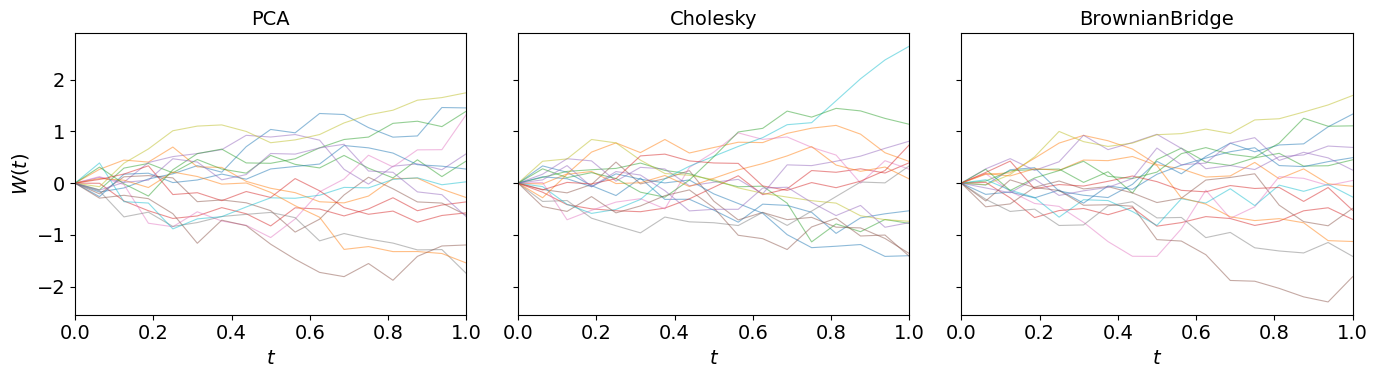

In [5]:
d = 16
n = 16
t_final = 1.0

fig, axes = pyplot.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, decomp in zip(axes, ['PCA', 'Cholesky', 'BrownianBridge']):
    bm = BrownianMotion(DigitalNetB2(d, seed=7), t_final=t_final, decomp_type=decomp)
    paths = bm.gen_samples(n)
    time_vec = np.concatenate([[0], bm.time_vec])
    paths_with_origin = np.hstack([np.zeros((n, 1)), paths])
    for path in paths_with_origin:
        ax.plot(time_vec, path, alpha=0.5, linewidth=0.8)
    ax.set_title(decomp)
    ax.set_xlabel('$t$')
    ax.set_xlim(0, t_final)
axes[0].set_ylabel('$W(t)$')
pyplot.tight_layout()
pyplot.show()

## Option Pricing

An Asian call option priced under each `decomp_type`:

In [6]:
d = 16        # monitoring dates
n = 2**10     # QMC samples
vol = 0.2     # volatility
S0 = 100.0    # initial stock price
K = 100.0     # strike price
r = 0.05      # risk-free rate
t_final = 1.0 # time horizon (years)

In [7]:
print(f"{'decomp_type':<16}  {'price':>8}")
print('-' * 28)
for decomp in ['PCA', 'Cholesky', 'BrownianBridge']:
    option = FinancialOption(
        DigitalNetB2(d, seed=7),
        option='ASIAN',
        volatility=vol,
        start_price=S0,
        strike_price=K,
        interest_rate=r,
        t_final=t_final,
        call_put='call',
        asian_mean='arithmetic',
        decomp_type=decomp,
    )
    print(f"{decomp:<16}  {option(n).mean():>8.4f}")

decomp_type          price
----------------------------
PCA                 5.7618
Cholesky            5.7432
BrownianBridge      5.7505
